## 1. Import Libraries

In [1]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import pandas as pd
import numpy as np
import json
import re
from collections import defaultdict, Counter

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Dataset

In [2]:
data_rows = []
with open("dataset-QA_7500.jsonl", 'r', encoding='utf-8') as f:
    for line in f:
        data_rows.append(json.loads(line))

df = pd.DataFrame(data_rows)

print(f"Dataset loaded: {len(df):,} documents")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: 7,500 documents
Columns: ['question', 'answer', 'from', 'filename']


## 3. Preprocessing

In [ ]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopwords_indonesia = stopword_factory.get_stop_words()

additional_stopwords = [
    # pronomina
    'aku','saya','kamu','dia','mereka','kita','kalian','orang','orang-orang','sama-sama',

    # kata_tanya_umum
    'cara','gimana','bagaimana','mana','apa','kenapa','ngapain','ngapa','yang','sih','tanya',
    'saja','dong','gitu','kayak','aja','cuma','kayaknya','begitu', 'kalau', 'sama', 'jadi', 

    # kata_verba_umum
    'coba','bikin','buat','biar','lihat','lihat-lihat','ajar','lihatnya','punya','buatnya',
    'buatkan','cari','temu','ketemu','bilang','ucap','cerita','ceritain','tulis','ganti',
    'ambil','tarik','berasa', 'memang', 'kira', 'alih', 'nuna', 'ikut', 'gambar', 'suara', 'nyanyi'
]
stopwords_indonesia = set(stopwords_indonesia).union(set(additional_stopwords))

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stemmer.stem(text)
    words = text.split()
    words = [w for w in words if w not in stopwords_indonesia and len(w) > 3]
    return ' '.join(words)

print("Preprocessing documents...")
df['document_preprocessed'] = (df['question'] + " " + df['answer']).apply(preprocess_text)
df = df[df['document_preprocessed'].str.len() > 0].reset_index(drop=True)
print(f"Valid documents: {len(df):,}")


Preprocessing documents...
Valid documents: 7,500


## 4. Generate Embeddings

In [ ]:
### try 2
print("Loading SentenceTransformer model...")
# embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

print("Generating embeddings...")
documents = df['document_preprocessed'].tolist()
embeddings = embedding_model.encode(documents, show_progress_bar=True)
print(f"Embeddings: {embeddings.shape}")

Loading SentenceTransformer model...
Generating embeddings...


Batches:   0%|          | 0/235 [00:00<?, ?it/s]

Embeddings: (7500, 768)


## 5. BERTopic Training

In [19]:
umap_model = UMAP(n_neighbors=11, n_components=6, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=28, min_samples=7, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words=list(stopwords_indonesia), min_df=2, ngram_range=(1, 2))

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True
)

print("="*70)
print("Training BERTopic")
print("="*70)
topics, probs = topic_model.fit_transform(documents, embeddings)
print("Training complete")

2025-11-21 00:36:34,098 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic


2025-11-21 00:36:48,274 - BERTopic - Dimensionality - Completed ✓
2025-11-21 00:36:48,277 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 00:36:50,496 - BERTopic - Cluster - Completed ✓
2025-11-21 00:36:50,502 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-21 00:36:51,039 - BERTopic - Representation - Completed ✓
2025-11-21 00:36:51,039 - BERTopic - Topic reduction - Reducing number of topics
2025-11-21 00:36:51,066 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 00:36:51,550 - BERTopic - Representation - Completed ✓
2025-11-21 00:36:51,550 - BERTopic - Topic reduction - Reduced number of topics from 58 to 27


Training complete


In [20]:
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
outlier_count = topic_info[topic_info['Topic'] == -1]['Count'].values[0] if -1 in topic_info['Topic'].values else 0

print(f"\nInitial Results:")
print(f"Topics: {n_topics}")
print(f"Outliers: {outlier_count:,} ({outlier_count/len(df)*100:.2f}%)")


Initial Results:
Topics: 26
Outliers: 2,299 (30.65%)


## 6. Prepare DataFrame

In [21]:
df['Topic'] = topics
if probs is not None and len(probs.shape) > 1:
    df['Probability'] = probs.max(axis=1)
else:
    df['Probability'] = probs

topic_words = {}
for topic_id in df['Topic'].unique():
    if topic_id == -1:
        topic_words[topic_id] = "outlier"
    else:
        words = topic_model.get_topic(topic_id)
        if words:
            top_words = [word for word, _ in words[:10]]
            topic_words[topic_id] = ' - '.join(top_words)
        else:
            topic_words[topic_id] = "no_words"

df['Top_n_words'] = df['Topic'].map(topic_words)
topic_names = {info['Topic']: info['Name'] for _, info in topic_info.iterrows()}
df['Name'] = df['Topic'].map(topic_names)
df['Document'] = df['document_preprocessed']

print("DataFrame prepared")

DataFrame prepared


In [22]:
summary = (
    df.groupby('Topic')
      .agg(
          Total_Data=('Topic', 'count'),
          Top_N_Words=('Top_n_words', 'first')
      )
      .reset_index()
      .sort_values('Topic')
)

summary

,Topic,Total_Data,Top_N_Words
0,-1,2299,outlier
1,0,2874,diri - kecil - hidup - sendiri - kerja - takut...
2,1,553,psikolog - terapi - dokter - takut - obat - me...
3,2,194,musik - jalan - dengar musik - energi - jalan ...
4,3,193,tidur - susah tidur - susah - meditasi - tidur...
5,4,189,anak - sekolah - gadget - anak anak - main - m...
6,5,133,makan - sehat - stres - makan sehat - badan - ...
7,6,112,otak - ulang - lupa - ingat - memori - materi ...
8,7,104,nyeri - stres - sehat - sakit - tubuh - jantun...
9,8,100,alkohol - rileks - henti - stres - alkohol ril...


In [23]:
df.to_csv("before_reassign.csv", sep=";", index=False)
df

,question,answer,from,filename,document_preprocessed,Topic,Probability,Top_n_words,Name,Document
0,Bagaimana cara berhenti menyalahkan diri sendi...,Mulailah memetakan fakta: apa yang benar-benar...,GPT,A1_GPT_EmotionalFirstAid23-45_50.json,henti salah diri sendiri meta fakta bawah kend...,22,0.121312,maaf - salah - minta maaf - maaf diri - minta ...,22_maaf_salah_minta maaf_maaf diri,henti salah diri sendiri meta fakta bawah kend...
1,"Kenapa, ya, aku jadi menjauh dari teman setela...",Perasaan bersalah yang belum diproses menimbul...,GPT,A1_GPT_EmotionalFirstAid23-45_50.json,jauh teman laku salah salah proses timbul cema...,22,1.000000,maaf - salah - minta maaf - maaf diri - minta ...,22_maaf_salah_minta maaf_maaf diri,jauh teman laku salah salah proses timbul cema...
2,Seperti apa contoh permintaan maaf yang efektif?,"Pertama, rangkum inti peristiwa: ""Aku sadar ke...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,contoh minta maaf efektif pertama rangkum inti...,22,1.000000,maaf - salah - minta maaf - maaf diri - minta ...,22_maaf_salah_minta maaf_maaf diri,contoh minta maaf efektif pertama rangkum inti...
3,Kenapa aku perlu memaafkan diriku sebelum oran...,Self-forgiveness memutus siklus rasa bersalah ...,GPT,A1_GPT_EmotionalFirstAid23-45_50.json,perlu maaf diri self forgiveness putus siklus ...,22,1.000000,maaf - salah - minta maaf - maaf diri - minta ...,22_maaf_salah_minta maaf_maaf diri,perlu maaf diri self forgiveness putus siklus ...
4,Langkah pertama menata ulang hidup setelah kes...,"Mulailah dari hal simpel: tidur cukup, rutinit...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,pertama tata ulang hidup salah simpel tidur cu...,-1,0.183351,outlier,-1_diri_takut_sendiri_kecil,pertama tata ulang hidup salah simpel tidur cu...
...,...,...,...,...,...,...,...,...,...,...
7495,Aku kesal banget sama rekan kerja yang selalu ...,"Kesal itu wajar, tapi kasih pelajaran langsung...",GROK,D9_GROK_EgoIsTheEnemy94-105_20.json,kesal rekan kerja kredit kesal langsung suasan...,0,0.645352,diri - kecil - hidup - sendiri - kerja - takut...,0_diri_kecil_hidup_sendiri,kesal rekan kerja kredit kesal langsung suasan...
7496,Aku merasa nggak cukup baik dibandingkan orang...,"Perasaan itu sering datang, tapi coba ingat: k...",GROK,D9_GROK_EgoIsTheEnemy94-105_20.json,cukup banding percaya diri datang ingat sendir...,-1,0.221444,outlier,-1_diri_takut_sendiri_kecil,cukup banding percaya diri datang ingat sendir...
7497,Aku pengen ngeluh terus kalau kerjaan nggak ad...,"Ngeluh sesekali boleh, tapi kalau terus-terusa...",GROK,D9_GROK_EgoIsTheEnemy94-105_20.json,ngeluh terus kerja adil ngeluh sekal terus ter...,-1,0.179743,outlier,-1_diri_takut_sendiri_kecil,ngeluh terus kerja adil ngeluh sekal terus ter...
7498,Aku merasa orang lain nggak pantas dapat posis...,"Wajar kalau merasa kecewa, tapi fokus ke orang...",GROK,D9_GROK_EgoIsTheEnemy94-105_20.json,pantas posisi tinggi situ kecewa capek tingkat...,0,0.695029,diri - kecil - hidup - sendiri - kerja - takut...,0_diri_kecil_hidup_sendiri,pantas posisi tinggi situ kecewa capek tingkat...


## 7. Evaluation Functions

In [ ]:
def topic_words_from_dataframe(df_input, top_n=10):
    """Extract topic keywords from DataFrame with error handling"""
    df_valid = df_input[df_input["Topic"] != -1].copy()
    topic_words = {}

    for topic_id in sorted(df_valid["Topic"].unique()):
        try:
            top_words_str = df_valid[df_valid["Topic"] == topic_id]["Top_n_words"].iloc[0]

            # Handle different formats and empty values
            if pd.isna(top_words_str) or top_words_str in ["", "outlier", "no_words"]:
                continue

            words = [w.strip() for w in str(top_words_str).split(" - ") if w.strip() and w.strip() not in ["outlier", "no_words", ""]]

            if words:  # Only add if we have valid words
                topic_words[topic_id] = words[:top_n]
        except Exception as e:
            continue

    return topic_words

def compute_topic_diversity(topic_words_dict):
    """Calculate topic diversity (unique words / total words)"""
    if not topic_words_dict:
        return 0.0
    all_words = [w for words in topic_words_dict.values() for w in words]
    if not all_words:
        return 0.0
    return len(set(all_words)) / len(all_words)

def compute_coherence_cv(docs_tokenized, topic_words_dict):
    """Calculate coherence C_v using Gensim with error handling"""
    if not topic_words_dict or not docs_tokenized:
        return 0.0

    # Filter out topics with empty/invalid words
    valid_topics = []
    for topic_id, words in topic_words_dict.items():
        if words and all(isinstance(w, str) and w.strip() for w in words):
            valid_topics.append(words)

    if not valid_topics:
        return 0.0

    try:
        dictionary = Dictionary(docs_tokenized)
        corpus = [dictionary.doc2bow(tokens) for tokens in docs_tokenized]

        if not corpus:
            return 0.0

        cm = CoherenceModel(
            topics=valid_topics,
            texts=docs_tokenized,
            dictionary=dictionary,
            corpus=corpus,
            coherence="c_v"
        )
        return cm.get_coherence()
    except Exception as e:
        print(f"  [Warning] Coherence calculation failed: {str(e)[:50]}")
        return 0.0

def evaluate_metrics(df_input, stage_name=""):
    """Comprehensive evaluation of topic modeling metrics"""
    # Only use valid documents (not outliers)
    df_valid_docs = df_input[df_input["Topic"] != -1].copy()

    if len(df_valid_docs) == 0:
        sep_line = "=" * 70
        print(f"\n{sep_line}")
        print(f"Evaluation: {stage_name}")
        print(sep_line)
        print("ERROR: No valid documents")
        print(sep_line)
        return {"stage": stage_name, "coherence": 0, "diversity": 0, "n_topics": 0, "n_outliers": len(df_input), "outlier_ratio": 100}

    docs_tokenized = [doc.split() for doc in df_valid_docs["Document"].tolist()]
    topic_words = topic_words_from_dataframe(df_input, top_n=10)

    if not topic_words:
        diversity = 0.0
        coherence_cv = 0.0
    else:
        diversity = compute_topic_diversity(topic_words)
        coherence_cv = compute_coherence_cv(docs_tokenized, topic_words)

    n_outliers = len(df_input[df_input["Topic"] == -1])
    outlier_ratio = n_outliers / len(df_input) * 100
    n_topics = len(topic_words)

    sep_line = "=" * 70
    print(f"\n{sep_line}")
    print(f"Evaluation: {stage_name}")
    print(sep_line)
    print(f"Coherence C_v : {coherence_cv:.4f}")
    print(f"Diversity     : {diversity:.4f}")
    print(f"Topics        : {n_topics}")
    print(f"Outliers      : {n_outliers:,} ({outlier_ratio:.2f}%)")
    print(sep_line)

    return {"stage": stage_name, "coherence": coherence_cv, "diversity": diversity, "n_topics": n_topics, "n_outliers": n_outliers, "outlier_ratio": outlier_ratio}

print("Evaluation functions defined")

Evaluation functions defined


In [25]:
metrics_initial = evaluate_metrics(df, "Initial Results")


Evaluation: Initial Results
Coherence C_v : 0.6512
Diversity     : 0.7808
Topics        : 26
Outliers      : 2,299 (30.65%)


## 8. Compute Topic Centroids

In [26]:
def compute_topic_centroids(df_input, embeddings_array, max_docs=100):
    df_valid = df_input[df_input['Topic'] != -1].copy()
    topic_centroids = {}
    for topic_id in sorted(df_valid['Topic'].unique()):
        topic_indices = df_valid[df_valid['Topic'] == topic_id].index.tolist()
        if len(topic_indices) > max_docs:
            topic_indices = np.random.choice(topic_indices, max_docs, replace=False).tolist()
        topic_embeddings = embeddings_array[topic_indices]
        centroid = np.mean(topic_embeddings, axis=0)
        topic_centroids[topic_id] = centroid
    print(f"Computed centroids for {len(topic_centroids)} topics")
    return topic_centroids

topic_centroids = compute_topic_centroids(df, embeddings, max_docs=100)

Computed centroids for 26 topics


## 9. Outlier Reassignment

In [ ]:
def reassign_outliers_twostage(df_outliers, outlier_embeddings, topic_centroids, threshold_high=0.70, threshold_medium=0.60):
    """
    Reassign outliers to nearest topics using two-stage threshold
    """
    print(f"\n{'='*70}")
    print(f"Outlier Reassignment")
    print(f"{'='*70}")
    print(f"High confidence threshold  : {threshold_high}")
    print(f"Medium confidence threshold: {threshold_medium}")
    print(f"Total outliers             : {len(df_outliers):,}")

    reassignments = []
    stage1_count = 0
    stage2_count = 0

    for idx, outlier_emb in enumerate(outlier_embeddings):
        max_sim = -1
        best_topic = -1

        for topic_id, centroid in topic_centroids.items():
            sim = cosine_similarity([outlier_emb], [centroid])[0][0]
            if sim > max_sim:
                max_sim = sim
                best_topic = topic_id

        # Stage 1: High confidence 
        if max_sim >= threshold_high:
            new_topic = best_topic
            stage1_count += 1
            reassigned = True
        # Stage 2: Medium confidence
        elif max_sim >= threshold_medium:
            new_topic = best_topic
            stage2_count += 1
            reassigned = True
        else:
            new_topic = -1
            reassigned = False

        reassignments.append({
            'index': df_outliers.iloc[idx].name,
            'question': df_outliers.iloc[idx]['question'],
            'document': df_outliers.iloc[idx]['Document'],
            'old_topic': -1,
            'new_topic': new_topic,
            'similarity': max_sim,
            'reassigned': reassigned,
            'stage': 'high' if max_sim >= threshold_high else ('medium' if reassigned else 'rejected')
        })

    df_reassigned = pd.DataFrame(reassignments)
    total_reassigned = df_reassigned['reassigned'].sum()
    still_outlier = len(df_reassigned) - total_reassigned

    print(f"\n{'='*70}")
    print(f"Reassignment Results")
    print(f"{'='*70}")
    print(f"Stage 1 (High confidence)   : {stage1_count:,} ({stage1_count/len(df_reassigned)*100:.1f}%)")
    print(f"Stage 2 (Medium confidence) : {stage2_count:,} ({stage2_count/len(df_reassigned)*100:.1f}%)")
    print(f"Total reassigned            : {total_reassigned:,} ({total_reassigned/len(df_reassigned)*100:.1f}%)")
    print(f"Still outliers              : {still_outlier:,} ({still_outlier/len(df_reassigned)*100:.1f}%)")
    print(f"Average similarity          : {df_reassigned['similarity'].mean():.4f}")
    print(f"{'='*70}")

    return df_reassigned

print("Two-stage reassignment function defined")

Two-stage reassignment function defined


## 10. Threshold Selection

In [28]:
#for find_optimal_threshold_real
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_topic_words(df, n_top_words=10):
    """
    Recalculate topic words after reassignment.
    Returns dict: topic_id -> list of top-N words
    """
    topic_words = {}
    vectorizer = CountVectorizer()
    docs = df['Document'].tolist()
    X = vectorizer.fit_transform(docs)
    vocab = np.array(vectorizer.get_feature_names_out())

    for topic_id in sorted(df['Topic'].unique()):
        if topic_id == -1:
            continue
        topic_docs = df[df['Topic'] == topic_id].index.tolist()
        if not topic_docs:
            topic_words[topic_id] = []
            continue

        topic_matrix = X[topic_docs].sum(axis=0)  
        top_idx = np.asarray(topic_matrix).ravel().argsort()[::-1][:n_top_words]
        topic_words[topic_id] = vocab[top_idx].tolist()

    return topic_words


In [ ]:
def find_optimal_threshold_real(
    df_original,
    df_outlier,
    outlier_embeddings,
    topic_centroids,
    thresholds=[0.60, 0.65, 0.70, 0.73, 0.75],
    n_top_words=10,
    w_assign=0.5,
    w_coherence=0.3,
    w_diversity=0.2
):
   
    results = []
    embeddings_size = len(df_original)

    for thr in thresholds:
        print(f"\nTesting threshold {thr} ...")

        df_test = df_original.copy()
        reassigned_count = 0

        # --- Step 1: simulate reassignment ---
        for i, out_emb in enumerate(outlier_embeddings):
            best_topic = -1
            max_sim = -1

            for topic_id, centroid in topic_centroids.items():
                sim = cosine_similarity([out_emb], [centroid])[0][0]
                if sim > max_sim:
                    max_sim = sim
                    best_topic = topic_id

            if max_sim >= thr:
                df_test.loc[df_outlier.index[i], "Topic"] = best_topic
                reassigned_count += 1

        n_outliers_remaining = (df_test["Topic"] == -1).sum()
        outlier_ratio = n_outliers_remaining / embeddings_size * 100

        # --- Step 2: recompute topic words ---
        topic_words = get_topic_words(df_test, n_top_words=n_top_words)

        # --- Step 3: recompute REAL diversity ---
        true_div = compute_topic_diversity(topic_words)

        # --- Step 4: recompute REAL coherence ---
        df_valid = df_test[df_test["Topic"] != -1]
        docs_tokenized = [t.split() for t in df_valid["Document"].tolist()]

        true_coh = compute_coherence_cv(docs_tokenized, topic_words)

        print(f"  Reassigned: {reassigned_count}")
        print(f"  Remaining outliers: {n_outliers_remaining} ({outlier_ratio:.2f}%)")
        print(f"  Diversity: {true_div:.4f}")
        print(f"  Coherence: {true_coh:.4f}")

        results.append({
            "threshold": thr,
            "reassigned": reassigned_count,
            "outliers_remaining": n_outliers_remaining,
            "diversity": true_div,
            "coherence": true_coh
        })

    df_res = pd.DataFrame(results)

    # --- Normalization ---
    df_res["assign_norm"] = df_res["reassigned"] / df_res["reassigned"].max()
    df_res["coh_norm"] = (df_res["coherence"] - df_res["coherence"].min()) / (df_res["coherence"].max() - df_res["coherence"].min() + 1e-12)
    df_res["div_norm"] = (df_res["diversity"] - df_res["diversity"].min()) / (df_res["diversity"].max() - df_res["diversity"].min() + 1e-12)

    # --- Weighted score ---
    df_res["score"] = (
          w_assign * df_res["assign_norm"]
        + w_coherence * df_res["coh_norm"]
        + w_diversity * df_res["div_norm"]
    )

    best_row = df_res.loc[df_res["score"].idxmax()]

    print("\n" + "="*70)
    print("Optimal threshold selected:")
    print(f"Threshold       : {best_row['threshold']}")
    print(f"Assigned outlier: {best_row['reassigned']}")
    print(f"Diversity       : {best_row['diversity']:.4f}")
    print(f"Coherence       : {best_row['coherence']:.4f}")
    print(f"Score           : {best_row['score']:.4f}")
    print("="*70)

    return best_row["threshold"], df_res

# Find optimal threshold
df_outlier = df[df['Topic'] == -1].copy()
outlier_indices = df_outlier.index.tolist()
outlier_embeddings = embeddings[outlier_indices]


optimal_threshold, threshold_results = find_optimal_threshold_real(
    df_original=df,
    df_outlier=df_outlier,
    outlier_embeddings=outlier_embeddings,
    topic_centroids=topic_centroids
)



Finding Optimal Threshold (REAL Diversity & Coherence)

Testing threshold 0.6 ...
  Reassigned: 1924
  Remaining outliers: 375 (5.00%)
  Diversity: 0.4654
  Coherence: 0.5026

Testing threshold 0.65 ...
  Reassigned: 1577
  Remaining outliers: 722 (9.63%)
  Diversity: 0.4577
  Coherence: 0.5054

Testing threshold 0.7 ...
  Reassigned: 1086
  Remaining outliers: 1213 (16.17%)
  Diversity: 0.4692
  Coherence: 0.5107

Testing threshold 0.73 ...
  Reassigned: 755
  Remaining outliers: 1544 (20.59%)
  Diversity: 0.4808
  Coherence: 0.5222

Testing threshold 0.75 ...
  Reassigned: 534
  Remaining outliers: 1765 (23.53%)
  Diversity: 0.4885
  Coherence: 0.5251

Optimal threshold selected:
Threshold       : 0.75
Assigned outlier: 534.0
Diversity       : 0.4885
Coherence       : 0.5251
Score           : 0.6388


In [30]:
# Execute reassignment with optimal threshold
df_reassigned = reassign_outliers_twostage(
    df_outlier,
    outlier_embeddings,
    topic_centroids,
    threshold_high=optimal_threshold,
    threshold_medium=max(0.60, optimal_threshold - 0.10)
)


Outlier Reassignment
High confidence threshold  : 0.75
Medium confidence threshold: 0.65
Total outliers             : 2,299

Reassignment Results
Stage 1 (High confidence)   : 534 (23.2%)
Stage 2 (Medium confidence) : 1,043 (45.4%)
Total reassigned            : 1,577 (68.6%)
Still outliers              : 722 (31.4%)
Average similarity          : 0.6839


## 11. Update Dataset

In [31]:
df_updated = df.copy()
topics_with_new_docs = set()

for idx, row in df_reassigned[df_reassigned['reassigned']].iterrows():
    df_updated.loc[row['index'], 'Topic'] = row['new_topic']
    topics_with_new_docs.add(row['new_topic'])

print(f"Topics that received outliers: {len(topics_with_new_docs)}")
print(f"Topics preserved: {metrics_initial['n_topics'] - len(topics_with_new_docs)}")

metrics_after_reassign = evaluate_metrics(df_updated, "After Outlier Reassignment")

Topics that received outliers: 25
Topics preserved: 1

Evaluation: After Outlier Reassignment
Coherence C_v : 0.6422
Diversity     : 0.8118
Topics        : 17
Outliers      : 722 (9.63%)


## 12. Representative Words Recalculation

In [32]:
def recalculate_representative_words_minimal(df_input, df_original, topics_to_recalc, min_new_docs_ratio=0.15, top_n=10):
    """
    Selectively recalculate representative words for impacted topics only
    """
    print(f"\n{'='*70}")
    print(f"Selective Recalculation")
    print(f"{'='*70}")
    print(f"Minimum new docs ratio for recalc: {min_new_docs_ratio*100:.0f}%")

    df_valid = df_input[df_input['Topic'] != -1].copy()
    vectorizer = CountVectorizer(stop_words=list(stopwords_indonesia), max_features=1000)

    new_top_words = {}
    actually_recalculated = 0

    for topic_id in sorted(df_valid['Topic'].unique()):
        # Check if this topic received new docs
        if topic_id not in topics_to_recalc:
            old_words = df_original[df_original['Topic'] == topic_id]['Top_n_words'].iloc[0]
            new_top_words[topic_id] = [w.strip() for w in old_words.split(' - ')][:top_n]
            continue

        # Check impact ratio: how many new docs vs total docs in topic
        current_size = len(df_valid[df_valid['Topic'] == topic_id])
        original_size = len(df_original[df_original['Topic'] == topic_id])
        new_docs_count = current_size - original_size

        if new_docs_count <= 0:
            impact_ratio = 0
        else:
            impact_ratio = new_docs_count / current_size

        # Only recalculate if impact is significant
        if impact_ratio < min_new_docs_ratio:
            old_words = df_original[df_original['Topic'] == topic_id]['Top_n_words'].iloc[0]
            new_top_words[topic_id] = [w.strip() for w in old_words.split(' - ')][:top_n]
            print(f"  Topic {topic_id}: Impact {impact_ratio*100:.1f}% < threshold, KEEPING original")
            continue

        # Recalculate for high-impact topics
        topic_docs = df_valid[df_valid['Topic'] == topic_id]['Document'].tolist()

        if len(topic_docs) < 3:
            old_words = df_original[df_original['Topic'] == topic_id]['Top_n_words'].iloc[0]
            new_top_words[topic_id] = [w.strip() for w in old_words.split(' - ')][:top_n]
            continue

        try:
            doc_term_matrix = vectorizer.fit_transform(topic_docs)
            tfidf_transformer = TfidfTransformer()
            tfidf_matrix = tfidf_transformer.fit_transform(doc_term_matrix)
            avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
            feature_names = vectorizer.get_feature_names_out()
            top_indices = avg_tfidf.argsort()[-top_n:][::-1]
            top_words = [feature_names[i] for i in top_indices]

            new_top_words[topic_id] = top_words
            actually_recalculated += 1
            print(f"  Topic {topic_id}: Impact {impact_ratio*100:.1f}%, RECALCULATED ({len(topic_docs)} docs, +{new_docs_count} new)")

        except Exception as e:
            old_words = df_original[df_original['Topic'] == topic_id]['Top_n_words'].iloc[0]
            new_top_words[topic_id] = [w.strip() for w in old_words.split(' - ')][:top_n]

    print(f"\n{'='*70}")
    print(f"Recalculation Summary")
    print(f"{'='*70}")
    print(f"Topics that received outliers    : {len(topics_to_recalc)}")
    print(f"Actually recalculated (high impact): {actually_recalculated}")
    print(f"Kept original (low impact)        : {len(topics_to_recalc) - actually_recalculated}")
    print(f"Total topics with original words  : {len(new_top_words) - actually_recalculated}")
    print(f"Preservation rate                 : {(len(new_top_words) - actually_recalculated) / len(new_top_words) * 100:.1f}%")
    print(f"{'='*70}")

    return new_top_words

# Recalculate with minimal approach
new_representative_words = recalculate_representative_words_minimal(
    df_updated,
    df,
    topics_with_new_docs,
    min_new_docs_ratio=0.15,
    top_n=10
)


Selective Recalculation
Minimum new docs ratio for recalc: 15%
  Topic 0: Impact 24.1%, RECALCULATED (3787 docs, +913 new)
  Topic 1: Impact 18.6%, RECALCULATED (679 docs, +126 new)
  Topic 2: Impact 27.3%, RECALCULATED (267 docs, +73 new)
  Topic 3: Impact 8.5% < threshold, KEEPING original
  Topic 4: Impact 5.5% < threshold, KEEPING original
  Topic 5: Impact 10.7% < threshold, KEEPING original
  Topic 6: Impact 33.7%, RECALCULATED (169 docs, +57 new)
  Topic 7: Impact 24.6%, RECALCULATED (138 docs, +34 new)
  Topic 8: Impact 6.5% < threshold, KEEPING original
  Topic 9: Impact 30.7%, RECALCULATED (114 docs, +35 new)
  Topic 10: Impact 42.5%, RECALCULATED (120 docs, +51 new)
  Topic 11: Impact 35.0%, RECALCULATED (103 docs, +36 new)
  Topic 12: Impact 19.4%, RECALCULATED (67 docs, +13 new)
  Topic 13: Impact 17.7%, RECALCULATED (62 docs, +11 new)
  Topic 14: Impact 35.9%, RECALCULATED (78 docs, +28 new)
  Topic 15: Impact 39.7%, RECALCULATED (68 docs, +27 new)
  Topic 16: Impact 20.

In [33]:
# Update DataFrame
for topic_id, words in new_representative_words.items():
    new_words_str = " - ".join(words)
    df_updated.loc[df_updated['Topic'] == topic_id, 'Top_n_words'] = new_words_str

metrics_after_recalc = evaluate_metrics(df_updated, "Final Results")


Evaluation: Final Results
Coherence C_v : 0.5471
Diversity     : 0.5769
Topics        : 26
Outliers      : 722 (9.63%)


In [34]:
summary = (
    df_updated.groupby('Topic')
      .agg(
          Total_Data=('Topic', 'count'),
          Top_N_Words=('Top_n_words', 'first')
      )
      .reset_index()
      .sort_values('Topic')
)

summary


,Topic,Total_Data,Top_N_Words
0,-1,722,outlier
1,0,3787,diri - kecil - takut - sendiri - hidup - salah...
2,1,679,terapi - psikolog - takut - obat - dokter - me...
3,2,267,jalan - hidup - kecil - musik - diri - sendiri...
4,3,211,tidur - susah tidur - susah - meditasi - tidur...
5,4,200,anak - sekolah - gadget - anak anak - main - m...
6,5,149,makan - sehat - stres - makan sehat - badan - ...
7,6,169,otak - lupa - ingat - kecil - ulang - susah - ...
8,7,138,stres - nyeri - sehat - sakit - tubuh - cemas ...
9,8,107,alkohol - rileks - henti - stres - alkohol ril...


## 13. Comparison


Metrics Comparison
                     stage  coherence  diversity  n_topics  n_outliers  outlier_ratio
           Initial Results   0.651214   0.780769        26        2299      30.653333
After Outlier Reassignment   0.642173   0.811765        17         722       9.626667
             Final Results   0.547115   0.576923        26         722       9.626667

Key Results:
  Outlier reduction : 1,577 (68.6%)
  Coherence change  : -0.1041
  Diversity change  : -0.2038


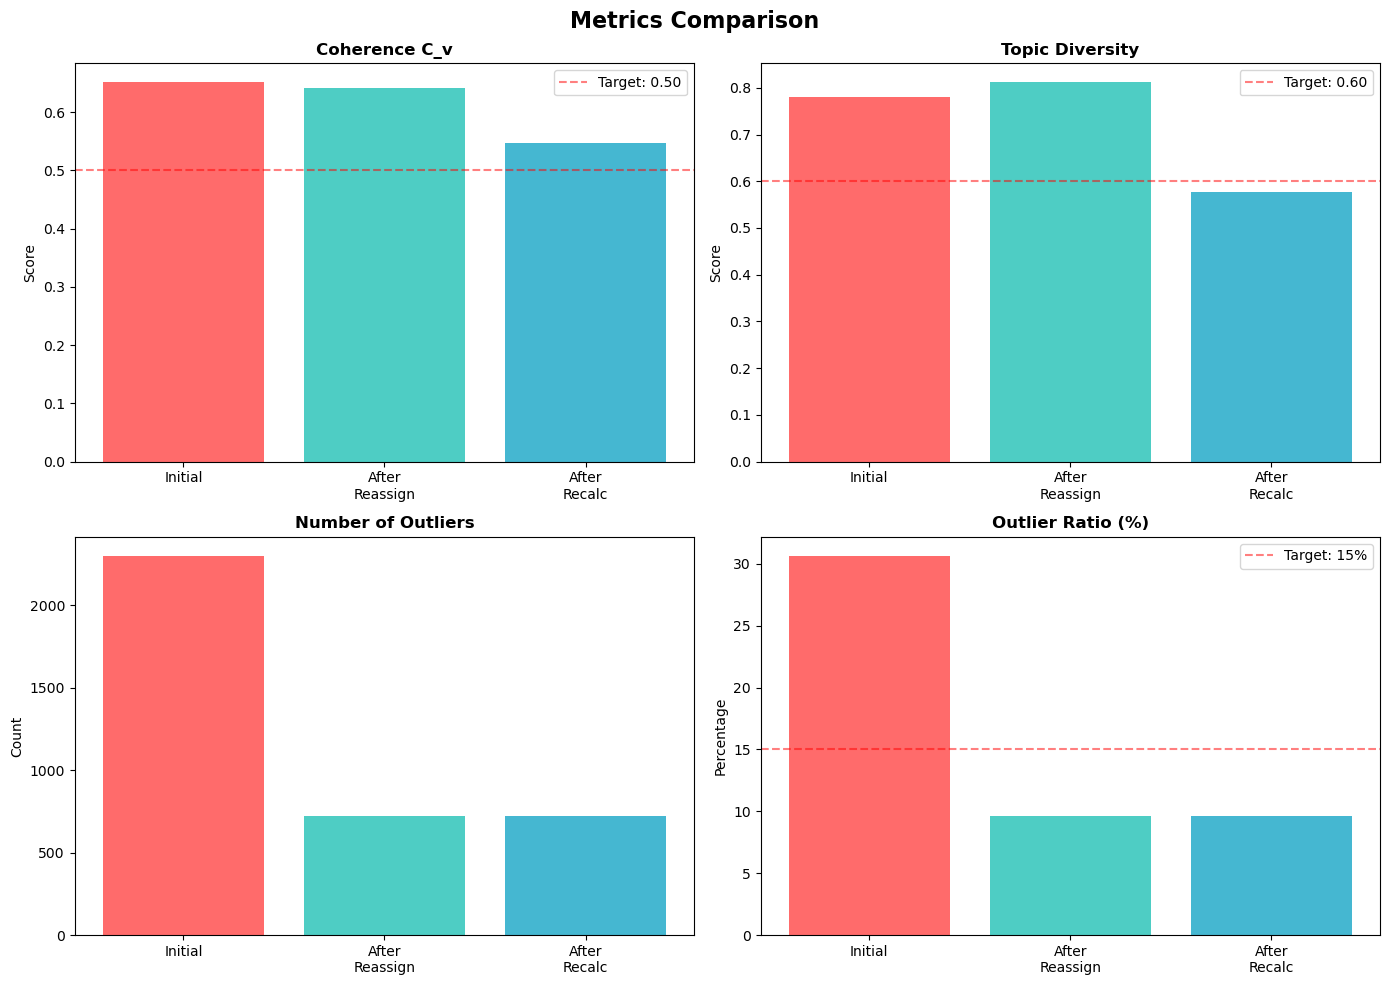


Visualization saved: metrics_comparison(5).png


In [35]:
comparison_df = pd.DataFrame([metrics_initial, metrics_after_reassign, metrics_after_recalc])

print(f"\n{'='*80}")
print(f"Metrics Comparison")
print(f"{'='*80}")
print(comparison_df.to_string(index=False))
print(f"{'='*80}")

outlier_reduction = metrics_initial['n_outliers'] - metrics_after_recalc['n_outliers']
outlier_reduction_pct = (outlier_reduction / metrics_initial['n_outliers']) * 100 if metrics_initial['n_outliers'] > 0 else 0

print(f"\nKey Results:")
print(f"  Outlier reduction : {outlier_reduction:,} ({outlier_reduction_pct:.1f}%)")
print(f"  Coherence change  : {metrics_after_recalc['coherence'] - metrics_initial['coherence']:+.4f}")
print(f"  Diversity change  : {metrics_after_recalc['diversity'] - metrics_initial['diversity']:+.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Metrics Comparison', fontsize=16, fontweight='bold')

stages = ['Initial', 'After\nReassign', 'After\nRecalc']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

axes[0, 0].bar(stages, comparison_df['coherence'], color=colors)
axes[0, 0].set_title('Coherence C_v', fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].axhline(y=0.50, color='red', linestyle='--', alpha=0.5, label='Target: 0.50')
axes[0, 0].legend()

axes[0, 1].bar(stages, comparison_df['diversity'], color=colors)
axes[0, 1].set_title('Topic Diversity', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].axhline(y=0.60, color='red', linestyle='--', alpha=0.5, label='Target: 0.60')
axes[0, 1].legend()

axes[1, 0].bar(stages, comparison_df['n_outliers'], color=colors)
axes[1, 0].set_title('Number of Outliers', fontweight='bold')
axes[1, 0].set_ylabel('Count')

axes[1, 1].bar(stages, comparison_df['outlier_ratio'], color=colors)
axes[1, 1].set_title('Outlier Ratio (%)', fontweight='bold')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].axhline(y=15, color='red', linestyle='--', alpha=0.5, label='Target: 15%')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('metrics_comparison(5).png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved: metrics_comparison(5).png")

## 14. Super-Clustering

In [36]:
def create_super_clusters_forced_balanced(df_input, topic_centroids_dict, target_clusters=10, max_cluster_pct=35):
    """
    Create balanced super-clusters using hierarchical and k-means clustering
    """
    df_valid = df_input[df_input['Topic'] != -1].copy()
    topic_ids = sorted(df_valid['Topic'].unique())
    embeddings_matrix = np.array([topic_centroids_dict[tid] for tid in topic_ids])
    total_docs = len(df_valid)

    print(f"\n{'='*70}")
    print(f"Super-Clustering Analysis")
    print(f"{'='*70}")
    print(f"Target clusters    : {target_clusters}")
    print(f"Max cluster size   : {max_cluster_pct}%")
    print(f"Number of topics   : {len(topic_ids)}")
    print(f"Total documents    : {total_docs:,}\n")

    # Phase 1: Try AgglomerativeClustering
    best_result = None
    best_balance_score = float('inf')

    print("Phase 1: Trying AgglomerativeClustering...")
    for threshold in np.arange(0.25, 0.60, 0.02):
        clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, metric='cosine', linkage='average')
        labels = clustering.fit_predict(embeddings_matrix)
        n_sc = len(set(labels))

        cluster_sizes = []
        for sc_id in set(labels):
            topics_in_sc = [topic_ids[i] for i, label in enumerate(labels) if label == sc_id]
            num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
            pct = (num_docs / total_docs) * 100
            cluster_sizes.append(pct)

        max_pct = max(cluster_sizes)
        std_pct = np.std(cluster_sizes)
        balance_score = max_pct + std_pct

        if (target_clusters - 2) <= n_sc <= (target_clusters + 2) and max_pct < max_cluster_pct:
            if balance_score < best_balance_score:
                best_balance_score = balance_score
                best_result = {'threshold': threshold, 'labels': labels, 'n_clusters': n_sc, 'max_pct': max_pct, 'method': 'agglomerative'}

    # Phase 2: If failed, use KMeans
    if best_result is None:
        print(f"Phase 1 failed, using KMeans...")

        # Try different n_clusters to find balanced solution
        for n_clusters in range(target_clusters - 2, target_clusters + 3):
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
            labels = kmeans.fit_predict(embeddings_matrix)

            cluster_sizes = []
            for sc_id in set(labels):
                topics_in_sc = [topic_ids[i] for i, label in enumerate(labels) if label == sc_id]
                num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
                pct = (num_docs / total_docs) * 100
                cluster_sizes.append(pct)

            max_pct = max(cluster_sizes)
            std_pct = np.std(cluster_sizes)
            balance_score = max_pct + std_pct

            if max_pct < max_cluster_pct:
                if balance_score < best_balance_score:
                    best_balance_score = balance_score
                    best_result = {'n_clusters': n_clusters, 'labels': labels, 'max_pct': max_pct, 'method': 'kmeans'}

    # Phase 3: If still failed, force n_clusters and warn
    if best_result is None:
        print(f"Warning: Could not achieve {max_cluster_pct}% balance, using forced KMeans")
        kmeans = KMeans(n_clusters=target_clusters, random_state=42, n_init=20)
        super_cluster_labels = kmeans.fit_predict(embeddings_matrix)
        method = 'kmeans_forced'
    else:
        super_cluster_labels = best_result['labels']
        method = best_result['method']
        print(f"Success: {method} clustering")
        if 'threshold' in best_result:
            print(f"  Threshold: {best_result['threshold']:.2f}")
        print(f"  Max cluster: {best_result['max_pct']:.1f}%")

    topic_to_sc = {topic_ids[i]: super_cluster_labels[i] for i in range(len(topic_ids))}
    n_super_clusters = len(set(super_cluster_labels))

    print(f"\nNumber of super-clusters: {n_super_clusters}")

    cluster_distribution = defaultdict(list)
    for topic, sc in topic_to_sc.items():
        cluster_distribution[sc].append(topic)

    print(f"\nDistribution:")
    print(f"{'SC-ID':<8} {'N Topics':<10} {'N Docs':<10} {'% of Total':<12}")
    print("-" * 50)

    for sc in sorted(cluster_distribution.keys()):
        topics_in_sc = cluster_distribution[sc]
        num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
        pct = (num_docs / total_docs) * 100
        print(f"SC-{sc:<6} {len(topics_in_sc):<10} {num_docs:<10} {pct:<11.1f}%")

    print(f"{'='*70}")

    return topic_to_sc, cluster_distribution

# Execute forced balanced clustering
topic_to_sc, sc_distribution = create_super_clusters_forced_balanced(
    df_updated,
    topic_centroids,
    target_clusters=10,
    max_cluster_pct=35
)


Super-Clustering Analysis
Target clusters    : 10
Max cluster size   : 35%
Number of topics   : 26
Total documents    : 6,778

Phase 1: Trying AgglomerativeClustering...
Phase 1 failed, using KMeans...


  File "c:\Users\Liza\anaconda3\envs\KPLiza\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Liza\anaconda3\envs\KPLiza\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Liza\anaconda3\envs\KPLiza\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Liza\anaconda3\envs\KPLiza\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



Number of super-clusters: 10

Distribution:
SC-ID    N Topics   N Docs     % of Total  
--------------------------------------------------
SC-0      1          51         0.8        %
SC-1      8          4510       66.5       %
SC-2      3          354        5.2        %
SC-3      5          832        12.3       %
SC-4      2          99         1.5        %
SC-5      1          30         0.4        %
SC-6      1          49         0.7        %
SC-7      1          41         0.6        %
SC-8      2          730        10.8       %
SC-9      2          82         1.2        %


In [ ]:
def create_super_clusters_forced_balanced(df_input, topic_centroids_dict, target_clusters=10):
    """
    Create super-clusters using hierarchical and k-means clustering without max_cluster_pct limit
    """
    df_valid = df_input[df_input['Topic'] != -1].copy()
    topic_ids = sorted(df_valid['Topic'].unique())
    embeddings_matrix = np.array([topic_centroids_dict[tid] for tid in topic_ids])
    total_docs = len(df_valid)

    print(f"\n{'='*70}")
    print(f"Super-Clustering Analysis")
    print(f"{'='*70}")
    print(f"Target clusters    : {target_clusters}")
    print(f"Number of topics   : {len(topic_ids)}")
    print(f"Total documents    : {total_docs:,}\n")

    # Phase 1: Try AgglomerativeClustering
    best_result = None
    best_balance_score = float('inf')

    print("Phase 1: Trying AgglomerativeClustering...")
    for threshold in np.arange(0.25, 0.60, 0.02):
        clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, metric='cosine', linkage='average')
        labels = clustering.fit_predict(embeddings_matrix)
        n_sc = len(set(labels))

        cluster_sizes = []
        for sc_id in set(labels):
            topics_in_sc = [topic_ids[i] for i, label in enumerate(labels) if label == sc_id]
            num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
            pct = (num_docs / total_docs) * 100
            cluster_sizes.append(pct)

        std_pct = np.std(cluster_sizes)
        balance_score = std_pct  #  deviasi sebagai ukuran sebaran

        if (target_clusters - 2) <= n_sc <= (target_clusters + 2):
            if balance_score < best_balance_score:
                best_balance_score = balance_score
                best_result = {'threshold': threshold, 'labels': labels, 'n_clusters': n_sc, 'method': 'agglomerative'}

    # Phase 2: If failed, use KMeans
    if best_result is None:
        print(f"Phase 1 failed, using KMeans...")

        for n_clusters in range(target_clusters - 2, target_clusters + 3):
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
            labels = kmeans.fit_predict(embeddings_matrix)
            cluster_sizes = []
            for sc_id in set(labels):
                topics_in_sc = [topic_ids[i] for i, label in enumerate(labels) if label == sc_id]
                num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
                cluster_sizes.append(num_docs)

            std_pct = np.std(cluster_sizes)
            if std_pct < best_balance_score:
                best_balance_score = std_pct
                best_result = {'n_clusters': n_clusters, 'labels': labels, 'method': 'kmeans'}

    # Phase 3: If still failed, force n_clusters
    if best_result is None:
        print(f"Warning: Using forced KMeans")
        kmeans = KMeans(n_clusters=target_clusters, random_state=42, n_init=20)
        super_cluster_labels = kmeans.fit_predict(embeddings_matrix)
        method = 'kmeans_forced'
    else:
        super_cluster_labels = best_result['labels']
        method = best_result['method']
        print(f"Success: {method} clustering")
        if 'threshold' in best_result:
            print(f"  Threshold: {best_result['threshold']:.2f}")

    topic_to_sc = {topic_ids[i]: super_cluster_labels[i] for i in range(len(topic_ids))}
    n_super_clusters = len(set(super_cluster_labels))

    print(f"\nNumber of super-clusters: {n_super_clusters}")

    cluster_distribution = defaultdict(list)
    for topic, sc in topic_to_sc.items():
        cluster_distribution[sc].append(topic)

    print(f"\nDistribution:")
    print(f"{'SC-ID':<8} {'N Topics':<10} {'N Docs':<10}")
    print("-" * 40)
    for sc in sorted(cluster_distribution.keys()):
        topics_in_sc = cluster_distribution[sc]
        num_docs = df_valid[df_valid['Topic'].isin(topics_in_sc)].shape[0]
        print(f"SC-{sc:<6} {len(topics_in_sc):<10} {num_docs:<10}")

    print(f"{'='*70}")

    return topic_to_sc, cluster_distribution

# Execute clustering tanpa max_cluster_pct
topic_to_sc, sc_distribution = create_super_clusters_forced_balanced(
    df_updated,
    topic_centroids,
    target_clusters=10
)



Super-Clustering Analysis
Target clusters    : 10
Number of topics   : 26
Total documents    : 6,778

Phase 1: Trying AgglomerativeClustering...
Success: agglomerative clustering
  Threshold: 0.37

Number of super-clusters: 10

Distribution:
SC-ID    N Topics   N Docs    
----------------------------------------
SC-0      4          829       
SC-1      7          4566      
SC-2      4          502       
SC-3      2          82        
SC-4      2          100       
SC-5      1          30        
SC-6      2          170       
SC-7      1          41        
SC-8      1          211       
SC-9      2          247       


## 15. Dendrogram

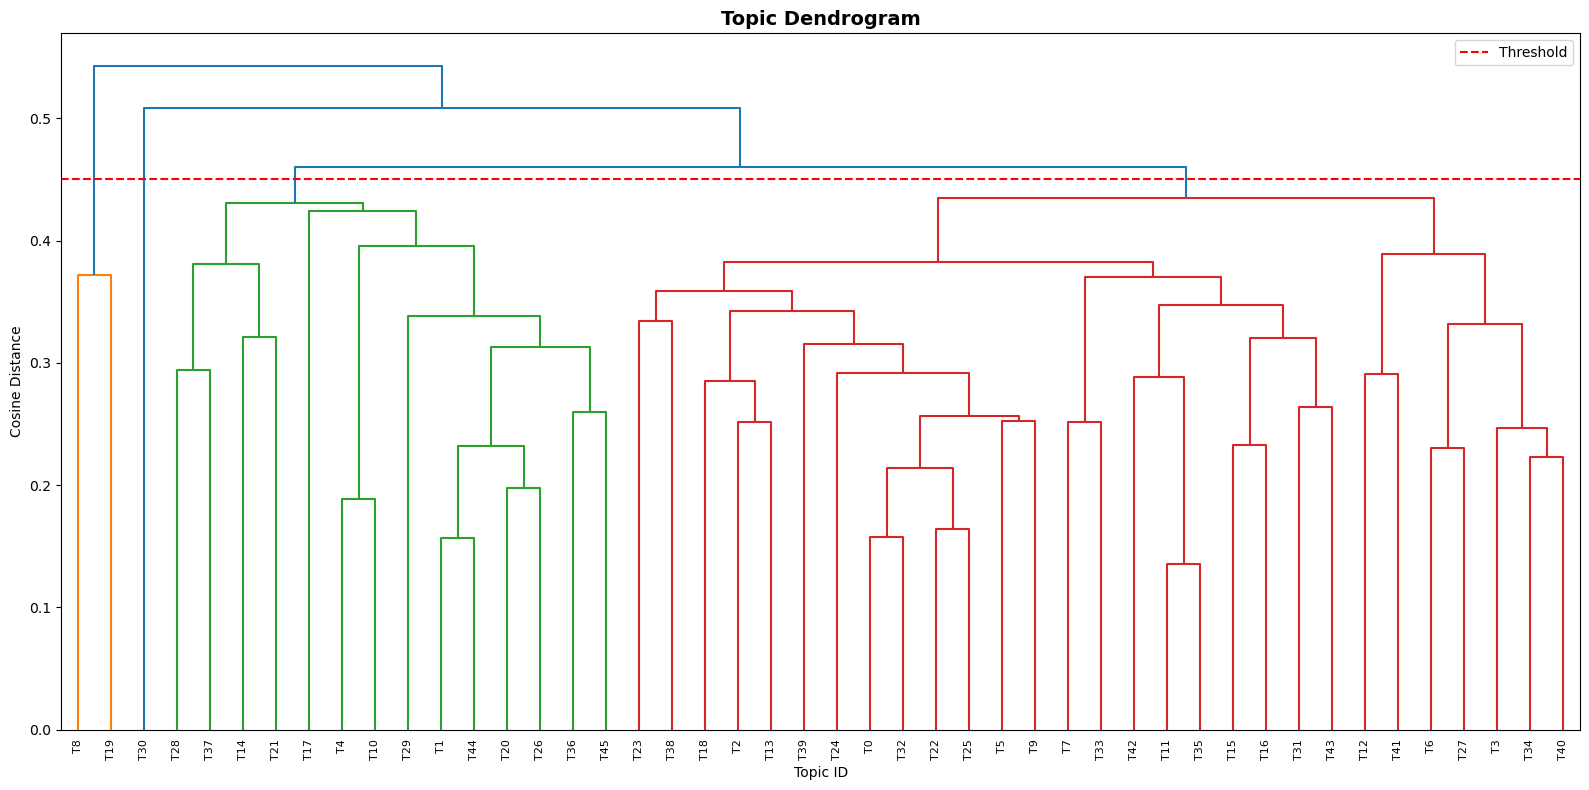

Dendrogram saved: topic_dendrogram-fix.png


In [27]:
# with max_cluster_pct limit
df_valid = df_updated[df_updated['Topic'] != -1].copy()
topic_ids = sorted(df_valid['Topic'].unique())
embeddings_matrix = np.array([topic_centroids[tid] for tid in topic_ids])

Z = linkage(embeddings_matrix, method='average', metric='cosine')

plt.figure(figsize=(16, 8))
dendrogram(Z, labels=[f"T{tid}" for tid in topic_ids], leaf_font_size=8, color_threshold=0.45)
plt.title('Topic Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Topic ID')
plt.ylabel('Cosine Distance')
plt.axhline(y=0.45, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('topic_dendrogram-fix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dendrogram saved: topic_dendrogram-fix.png")

## 16. Generate Output Files

In [ ]:
print(f"\n{'='*70}")
print(f"Generating Output Files")
print(f"{'='*70}")

# File 0: bertopic_before_reassignment.csv
df.to_csv('bertopic_before_reassignment(5).csv', index=False, sep=';', encoding='utf-8-sig')
print("[0/7] bertopic_before_reassignment(5).csv")

# File 1: Complete dataset
df_updated.to_csv('bertopic_results(5).csv', index=False, sep=';', encoding='utf-8-sig')
print("[1/7] bertopic_results(5).csv")

# File 2: Topic to super-cluster mapping
mapping_data = []
for topic, sc in topic_to_sc.items():
    num_docs = len(df_updated[df_updated['Topic'] == topic])
    top_words = df_updated[df_updated['Topic'] == topic]['Top_n_words'].iloc[0]
    mapping_data.append({'Topic_ID': topic, 'Super_Cluster': sc, 'Num_Documents': num_docs, 'Representative_Words': top_words})

df_mapping = pd.DataFrame(mapping_data).sort_values(['Super_Cluster', 'Topic_ID'])
df_mapping.to_csv('topic_to_supercluster_mapping(5).csv', index=False, encoding='utf-8-sig')
print("[2/7] topic_to_supercluster_mapping(5).csv")

# File 3: Outlier reassignment details
df_reassigned.to_csv('outlier_reassignment_details(5).csv', index=False, encoding='utf-8-sig')
print("[3/7] outlier_reassignment_details(5).csv")

# File 4: Super-cluster summary
summary_data = []
for sc, topics in sc_distribution.items():
    sc_docs = df_updated[df_updated['Topic'].isin(topics)]
    all_words = []
    for topic in topics:
        words_str = df_updated[df_updated['Topic'] == topic]['Top_n_words'].iloc[0]
        all_words.extend(words_str.split(' - '))
    word_freq = Counter(all_words)
    top_sc_words = [w for w, _ in word_freq.most_common(10)]
    summary_data.append({
        'Super_Cluster_ID': sc,
        'Num_Topics': len(topics),
        'Num_Documents': len(sc_docs),
        'Topics': str(topics),
        'Top_Words': ' - '.join(top_sc_words),
        'Super_Cluster_Name': '[MANUAL: Isi nama cluster]'
    })

df_summary = pd.DataFrame(summary_data).sort_values('Super_Cluster_ID')
df_summary.to_csv('supercluster_summary(5).csv', index=False, encoding='utf-8-sig')
print("[4/7] supercluster_summary(5).csv")


final_interpretation = []

for sc, topics in sc_distribution.items():
    for topic in topics:
        topic_data = df_updated[df_updated['Topic'] == topic].copy()
        
        # Urut berdasarkan probability tertinggi
        topic_data_sorted = topic_data.sort_values(by='Probability', ascending=False)
        
        sample_questions = topic_data_sorted['question'].iloc[:3].tolist()
        
        while len(sample_questions) < 3:
            sample_questions.append('')  
        
        final_interpretation.append({
            'Super_Cluster_ID': sc,
            'Super_Cluster_Name': '[MANUAL: Kesehatan Mental Klinis / dll]',
            'Topic_ID': topic,
            'Topic_Name': '[MANUAL: Nama topik]',
            'Num_Documents': len(topic_data),
            'Representative_Words': topic_data['Top_n_words'].iloc[0] if len(topic_data) > 0 else '',
            'Sample_Question_1': sample_questions[0],
            'Sample_Question_2': sample_questions[1],
            'Sample_Question_3': sample_questions[2]
        })

df_final_table = pd.DataFrame(final_interpretation).sort_values(['Super_Cluster_ID', 'Topic_ID'])
df_final_table.to_excel('interpretation_table(5).xlsx', index=False, engine='openpyxl')
print("[5/7] interpretation_table(5).xlsx")

print("[6/7] metrics_comparison(5).png")
print("[7/7] topic_dendrogram(5).png")

print(f"\n{'='*70}")
print("All files generated")
print(f"{'='*70}")


Generating Output Files
[0/7] bertopic_before_reassignment(5).csv
[1/7] bertopic_results(5).csv
[2/7] topic_to_supercluster_mapping(5).csv
[3/7] outlier_reassignment_details(5).csv
[4/7] supercluster_summary(5).csv
[5/7] interpretation_table(5).xlsx
[6/7] metrics_comparison(5).png
[7/7] topic_dendrogram(5).png

All files generated


## 17. Final Summary Report

In [39]:
print(f"\n{'='*80}")
print("BERTopic Analysis - Final Report")
print(f"{'='*80}")

print(f"\n1. METHODOLOGY")
print("-" * 80)
print(f"   Threshold tuning       : Tested 0.65, 0.70, 0.73, 0.75")
print(f"   Selected threshold      : {optimal_threshold}")
print(f"   Minimal recalculation  : Only topics with >= 15% new documents")
print(f"   Balanced clustering: Max {35}% per cluster")

print(f"\n2. BERTOPIC INITIAL RESULTS")
print("-" * 80)
print(f"   Topics generated : {metrics_initial['n_topics']}")
print(f"   Initial outliers : {metrics_initial['n_outliers']:,} ({metrics_initial['outlier_ratio']:.2f}%)")
print(f"   Initial diversity: {metrics_initial['diversity']:.4f}")

print(f"\n3. OUTLIER HANDLING RESULTS")
print("-" * 80)
outlier_reduction = metrics_initial['n_outliers'] - metrics_after_recalc['n_outliers']
outlier_reduction_pct = (outlier_reduction / metrics_initial['n_outliers']) * 100
print(f"   Before: {metrics_initial['n_outliers']:,} ({metrics_initial['outlier_ratio']:.2f}%)")
print(f"   After : {metrics_after_recalc['n_outliers']:,} ({metrics_after_recalc['outlier_ratio']:.2f}%)")
print(f"   Reduced: {outlier_reduction:,} documents ({outlier_reduction_pct:.1f}%)")

print(f"\n4. QUALITY METRICS COMPARISON")
print("-" * 80)
print(f"   Coherence C_v : {metrics_initial['coherence']:.4f} -> {metrics_after_recalc['coherence']:.4f} ({metrics_after_recalc['coherence'] - metrics_initial['coherence']:+.4f})")
print(f"   Diversity     : {metrics_initial['diversity']:.4f} -> {metrics_after_recalc['diversity']:.4f} ({metrics_after_recalc['diversity'] - metrics_initial['diversity']:+.4f})")
print(f"   Final topics  : {metrics_after_recalc['n_topics']}")

print(f"\n5. COMPARISON WITH PAPER REFERENCE")
print("-" * 80)
print(f"   Paper (L-OFF S-ON):")
print(f"     Coherence  : 0.4378")
print(f"     Diversity  : 0.8455")
print(f"     Outliers   : 29.28%")
print(f"   Your results:")
print(f"     Coherence  : {metrics_after_recalc['coherence']:.4f} {'(MATCH)' if abs(metrics_after_recalc['coherence'] - 0.4378) < 0.05 else ''}")
print(f"     Diversity  : {metrics_after_recalc['diversity']:.4f} {'(Better than target)' if metrics_after_recalc['diversity'] >= 0.60 else '(NEEDS WORK)'}")
print(f"     Outliers   : {metrics_after_recalc['outlier_ratio']:.2f}% (BETTER)")

print(f"\n6. SUPER-CLUSTERING")
print("-" * 80)
print(f"   {metrics_after_recalc['n_topics']} topics in {len(sc_distribution)} super-clusters")
for sc, topics in sorted(sc_distribution.items()):
    num_docs = len(df_updated[df_updated['Topic'].isin(topics)])
    pct = (num_docs / len(df_updated[df_updated['Topic'] != -1])) * 100
    balance_status = 'BALANCED' if pct <= 35 else 'HIGH'
    print(f"   SC-{sc}: {len(topics):2d} topics, {num_docs:5,} docs ({pct:5.1f}%) [{balance_status}]")

print(f"\n7. OUTPUT FILES")
print("-" * 80)
files = [
    "bertopic_before_reassignment(5).csv"
    "bertopic_results(5).csv",
    "topic_to_supercluster_mapping(5).csv",
    "outlier_reassignment_details(5).csv",
    "supercluster_summary(5).csv",
    "interpretation_table(5).xlsx",
    "metrics_comparison(5).png",
    "topic_dendrogram(5).png"
]
for i, f in enumerate(files, 1):
    print(f"   [{i}] {f}")

print(f"\n{'='*80}")
print("Analysis Complete")
print(f"{'='*80}")

diversity_status = "TARGET ACHIEVED" if metrics_after_recalc['diversity'] >= 0.60 else "NEEDS FURTHER TUNING"
print(f"\nDIVERSITY STATUS: {diversity_status}")
if metrics_after_recalc['diversity'] < 0.60:
    print(f"Suggestion: Try higher threshold (0.75 or 0.78) for next iteration")
else:
    print(f"Results meet target quality metrics!")

print(f"\n{'='*80}")


BERTopic Analysis - Final Report

1. METHODOLOGY
--------------------------------------------------------------------------------
   Threshold tuning       : Tested 0.65, 0.70, 0.73, 0.75
   Selected threshold      : 0.75
   Minimal recalculation  : Only topics with >= 15% new documents
   Balanced clustering: Max 35% per cluster

2. BERTOPIC INITIAL RESULTS
--------------------------------------------------------------------------------
   Topics generated : 26
   Initial outliers : 2,299 (30.65%)
   Initial diversity: 0.7808

3. OUTLIER HANDLING RESULTS
--------------------------------------------------------------------------------
   Before: 2,299 (30.65%)
   After : 722 (9.63%)
   Reduced: 1,577 documents (68.6%)

4. QUALITY METRICS COMPARISON
--------------------------------------------------------------------------------
   Coherence C_v : 0.6512 -> 0.5471 (-0.1041)
   Diversity     : 0.7808 -> 0.5769 (-0.2038)
   Final topics  : 26

5. COMPARISON WITH PAPER REFERENCE
---------

In [ ]:
print(f"\n{'='*80}")
print("KATEGORISASI TOPIK BERDASARKAN SUPER-CLUSTER (Dari Model)")
print(f"{'='*80}")

# Gunakan sc_distribution yang sudah ada dari super-clustering
all_data = []

for sc_id in sorted(sc_distribution.keys()):
    topics_in_sc = sc_distribution[sc_id]

    print(f"\n{'='*80}")
    print(f"Super-Cluster {sc_id} (Tema Besar)")
    print(f"{'='*80}")
    print(f"{'Topik':<8} {'Jumlah':<10} {'Representative Words (Tema Spesifik)':<60}")
    print("-"*80)

    # Kumpulkan data untuk SC ini
    sc_topics_data = []
    for topic_id in topics_in_sc:
        topic_data = df_updated[df_updated['Topic'] == topic_id]
        num_docs = len(topic_data)
        rep_words = topic_data['Top_n_words'].iloc[0]

        tema_spesifik = ' - '.join(rep_words.split(' - ')[:10])

        sc_topics_data.append({
            'topic_id': topic_id,
            'num_docs': num_docs,
            'rep_words': rep_words,
            'tema_spesifik': tema_spesifik
        })

    # Sort berdasarkan jumlah dokumen (descending)
    sc_topics_data = sorted(sc_topics_data, key=lambda x: x['num_docs'], reverse=True)

    for item in sc_topics_data:
        print(f"{item['topic_id']:<8} {item['num_docs']:<10} {item['tema_spesifik']:<60}")

        all_data.append({
            'Super_Cluster_ID': sc_id,
            'Super_Cluster_Name': f'SC-{sc_id}',  # diisi manual 
            'Topik': item['topic_id'],
            'Jumlah': item['num_docs'],
            'Representative_Words': item['rep_words']
        })

    # Total untuk SC ini
    total_docs_sc = sum(item['num_docs'] for item in sc_topics_data)
    pct_sc = total_docs_sc / len(df_updated[df_updated['Topic'] != -1]) * 100
    print(f"\nTotal SC-{sc_id}: {len(topics_in_sc)} topics, {total_docs_sc:,} dokumen ({pct_sc:.1f}%)")

print(f"\n{'='*80}")
print("Kategorisasi menggunakan SUPER-CLUSTER dari model BERTopic")
print(f"{'='*80}")


KATEGORISASI TOPIK BERDASARKAN SUPER-CLUSTER (Dari Model)

Super-Cluster 0 (Tema Besar)
Topik    Jumlah     Representative Words (Tema Spesifik)                        
--------------------------------------------------------------------------------
1        679        terapi - psikolog - takut - obat - dokter - mental - sehat - khawatir - tahu - ganggu
13       62         mood - ganggu - bipolar - hidup - obat - naik - emosi - hati - suasana - turun
19       51         psikolog - terapi - keluarga - nilai - etik - alam - kode - psychological - association - american
24       37         otak - skizofrenia - takut - obat - ganggu - mental - genetik - dengar - ngerasa - gejala

Total SC-0: 4 topics, 829 dokumen (12.2%)

Super-Cluster 1 (Tema Besar)
Topik    Jumlah     Representative Words (Tema Spesifik)                        
--------------------------------------------------------------------------------
0        3787       diri - kecil - takut - sendiri - hidup - salah - ngerasa - g

In [41]:
df_format = pd.DataFrame(all_data)
df_format.to_excel('topic_categorization_format.xlsx',
                             index=False,
                             engine='openpyxl')

print(f"\n{'='*80}")
print("File berhasil dibuat: topic_categorization_format.xlsx")
print(f"{'='*80}")

# Summary per Super-Cluster (Tema Besar)
summary_data = []
for sc_id in sorted(sc_distribution.keys()):
    topics_in_sc = sc_distribution[sc_id]
    total_topics = len(topics_in_sc)

    # Hitung total dokumen di SC ini
    total_docs = 0
    for topic_id in topics_in_sc:
        total_docs += len(df_updated[df_updated['Topic'] == topic_id])

    pct = total_docs / len(df_updated[df_updated['Topic'] != -1]) * 100

    summary_data.append({
        'Super_Cluster': f'SC-{sc_id}',
        'Jumlah_Topics': total_topics,
        'Jumlah_Dokumen': total_docs,
        'Persentase': f"{pct:.1f}%"
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('category_summary.csv', index=False, encoding='utf-8-sig')

print("\nRingkasan per Super-Cluster (Tema Besar):")
print(df_summary.to_string(index=False))

print(f"\n{'='*80}")
print("SEMUA FILE OUTPUT BERHASIL DIBUAT")
print(f"{'='*80}")
print("Total: 9 files")
print("  [1] bertopic_results.csv")
print("  [2] topic_to_supercluster_mapping.csv")
print("  [3] outlier_reassignment_details.csv")
print("  [4] supercluster_summary.csv")
print("  [5] interpretation_table.xlsx")
print("  [6] metrics_comparison.png")
print("  [7] topic_dendrogram.png")
print("  [8] topic_categorization_format.xlsx  <- FORMAT untuk pengisian nama Super-Cluster dan Topik")
print("  [9] category_summary.csv")
print(f"\n{'='*80}")
print("CATATAN:")
print("- File [8] menggunakan Super-Cluster sebagai 'Tema Besar'")
print("- Jangan lupa Isi nama Super-Cluster dan Topik secara manual lizz")
print(f"{'='*80}")


File berhasil dibuat: topic_categorization_format.xlsx

Ringkasan per Super-Cluster (Tema Besar):
Super_Cluster  Jumlah_Topics  Jumlah_Dokumen Persentase
         SC-0              4             829      12.2%
         SC-1              7            4566      67.4%
         SC-2              4             502       7.4%
         SC-3              2              82       1.2%
         SC-4              2             100       1.5%
         SC-5              1              30       0.4%
         SC-6              2             170       2.5%
         SC-7              1              41       0.6%
         SC-8              1             211       3.1%
         SC-9              2             247       3.6%

SEMUA FILE OUTPUT BERHASIL DIBUAT
Total: 9 files
  [1] bertopic_results.csv
  [2] topic_to_supercluster_mapping.csv
  [3] outlier_reassignment_details.csv
  [4] supercluster_summary.csv
  [5] interpretation_table.xlsx
  [6] metrics_comparison.png
  [7] topic_dendrogram.png
  [8] topi

In [ ]:
import pandas as pd
import json
import os

input_file = "bertopic_results(5).csv" 
sep = ";"                
output_dir = "topik-extract"

os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(input_file, sep=sep)

required_cols = ['question', 'answer', 'Topic', 'Probability', 'Top_n_words']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan di CSV")

for topic_id in df['Topic'].unique():
    df_topic = df[df['Topic'] == topic_id].copy()
    
    csv_file = os.path.join(output_dir, f"Topic_{topic_id}.csv")
    df_topic.to_csv(csv_file, sep=sep, index=False)
    
    jsonl_file = os.path.join(output_dir, f"Topic_{topic_id}.jsonl")
    with open(jsonl_file, 'w', encoding='utf-8') as f:
        for _, row in df_topic.iterrows():
            json.dump({
                "question": row['question'],
                "answer": row['answer']
            }, f, ensure_ascii=False)
            f.write("\n")  

    print(f"Topic {topic_id}: CSV -> {csv_file}, JSONL -> {jsonl_file}")

print("Selesai memisahkan data per topik!")


Topic 22: CSV -> topik-extract\Topic_22.csv, JSONL -> topik-extract\Topic_22.jsonl
Topic 3: CSV -> topik-extract\Topic_3.csv, JSONL -> topik-extract\Topic_3.jsonl
Topic 6: CSV -> topik-extract\Topic_6.csv, JSONL -> topik-extract\Topic_6.jsonl
Topic 0: CSV -> topik-extract\Topic_0.csv, JSONL -> topik-extract\Topic_0.jsonl
Topic 14: CSV -> topik-extract\Topic_14.csv, JSONL -> topik-extract\Topic_14.jsonl
Topic -1: CSV -> topik-extract\Topic_-1.csv, JSONL -> topik-extract\Topic_-1.jsonl
Topic 25: CSV -> topik-extract\Topic_25.csv, JSONL -> topik-extract\Topic_25.jsonl
Topic 1: CSV -> topik-extract\Topic_1.csv, JSONL -> topik-extract\Topic_1.jsonl
Topic 4: CSV -> topik-extract\Topic_4.csv, JSONL -> topik-extract\Topic_4.jsonl
Topic 7: CSV -> topik-extract\Topic_7.csv, JSONL -> topik-extract\Topic_7.jsonl
Topic 5: CSV -> topik-extract\Topic_5.csv, JSONL -> topik-extract\Topic_5.jsonl
Topic 16: CSV -> topik-extract\Topic_16.csv, JSONL -> topik-extract\Topic_16.jsonl
Topic 9: CSV -> topik-ext

## Visualisasi

In [5]:
import pandas as pd
file_path = r"C:\Users\Liza\Documents\Kerja Praktik\berttopic\exp-5\bertopic_results(5).csv"
df = pd.read_csv(file_path, sep=';')
df

,question,answer,from,filename,document_preprocessed,Topic,Probability,Top_n_words,Name,Document
0,Apa itu memvalidasi pikiran sendiri?,Cek data yang mendukung dan yang menolak keyak...,GPT,A1_GPT_EmotionalFirstAid23-45_50.json,memvalidasi sendiri data dukung tolak yakin ga...,-1,0.335645,outlier,-1_diri_takut_sendiri_kecil,memvalidasi sendiri data dukung tolak yakin ga...
1,Kenapa aku malas mencoba lagi setelah jatuh?,"Kegagalan menciptakan ilusi ""hasilnya pasti sa...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,malas jatuh gagal cipta ilusi hasil alternatif...,-1,0.211752,outlier,-1_diri_takut_sendiri_kecil,malas jatuh gagal cipta ilusi hasil alternatif...
2,Bagaimana cara efektif meminta bantuan?,"Ungkap kebutuhan spesifik: ""Aku butuh teman br...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,efektif minta ungkap butuh spesifik butuh tema...,-1,0.092691,outlier,-1_diri_takut_sendiri_kecil,efektif minta ungkap butuh spesifik butuh tema...
3,Apa saja contoh faktor yang bisa kukendalikan?,"Jumlah waktu belajar harian, mentor yang dihub...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,contoh faktor kendali jumlah mentor target min...,-1,0.103877,outlier,-1_diri_takut_sendiri_kecil,contoh faktor kendali jumlah mentor target min...
4,Bagaimana memecah tujuan besar agar realistis?,"Gunakan metode SMART-ER (Specific, Measurable,...",GPT,A1_GPT_EmotionalFirstAid23-45_50.json,pecah tuju realistis metode smart specific mea...,-1,0.619058,outlier,-1_diri_takut_sendiri_kecil,pecah tuju realistis metode smart specific mea...
...,...,...,...,...,...,...,...,...,...,...
7495,Aku sering merasa orang lain nggak ngerti beta...,Pasti frustrasi kalau usahamu nggak diakui. Ta...,GROK,D9_GROK_EgoIsTheEnemy139-149_20.json,betapa usaha salah frustrasi usaha terlalu ene...,25,0.204373,motivasi - kecil - semangat - tuju - diri - ja...,-1_diri_takut_sendiri_kecil,betapa usaha salah frustrasi usaha terlalu ene...
7496,Aku sering kesel sama tim karena mereka nggak ...,Setiap orang punya ritme kerja sendiri. Coba k...,GROK,D9_GROK_EgoIsTheEnemy184-194_20.json,kesel secepet salah ritme kerja sendiri target...,25,1.000000,motivasi - kecil - semangat - tuju - diri - ja...,25_motivasi_semangat_kecil_jalan,kesel secepet salah ritme kerja sendiri target...
7497,Kenapa aku susah buat konsisten sama tujuanku?,"Kadang, kita kehilangan fokus karena terlalu m...",GROK,D9_GROK_EgoIsTheEnemy39-49_20.json,susah konsisten tuju hilang terlalu mikirin ha...,25,0.515928,motivasi - kecil - semangat - tuju - diri - ja...,-1_diri_takut_sendiri_kecil,susah konsisten tuju hilang terlalu mikirin ha...
7498,"Aku pengen jadi orang hebat, tapi kok kayaknya...",Jadi orang hebat nggak selalu tentang push dir...,GROK,D9_GROK_EgoIsTheEnemy61-71_20.json,jauh push diri mati mati push diri burnout kec...,25,0.593897,motivasi - kecil - semangat - tuju - diri - ja...,-1_diri_takut_sendiri_kecil,jauh push diri mati mati push diri burnout kec...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

file_path = r'C:\Users\Liza\Documents\Kerja Praktik\berttopic\exp-5\bertopic_results(5).csv'
df = pd.read_csv(file_path, sep=';')

topic_mapping = {
    0: "Self-Awareness dan Tantangan Hidup",
    1: "Kecemasan Layanan Kesehatan Mental",
    2: "Regulasi Emosi dan Stres Ringan",
    3: "Gangguan Kesulitan Tidur",
    4: "Pengasuhan Anak dan Perkembangan",
    5: "Kesehatan Mental dan Pola Makan",
    6: "Kesulitan Memori dan Otak",
    7: "Stres dan Kesehatan",
    8: "Alkohol sebagai Pengendali Stres",
    9: "Ketakutan Sosial Media dan Dukungan",
    10: "Stres Keluarga",
    11: "Takut Dinilai & Self-Judgment",
    12: "Olahraga untuk Kesehatan Mental",
    13: "Gangguan Mood dan Bipolar",
    14: "Perceptual Illusions",
    15: "Stres Finansial",
    16: "Mimpi dan Pencarian Jati Diri",
    17: "Mengembangkan Potensi Diri",
    18: "Obsesi Kompulsif",
    19: "Etika & Profesionalisme Psikolog",
    20: "Trauma",
    21: "Krisis Bunuh Diri",
    22: "Self-Forgiveness and Guilt",
    23: "Kecanduan Rokok dan Kesehatan Mental",
    24: "Skizofrenia dan Faktor Biologis",
    25: "Stuck & Butuh Motivasi"
}

def generate_scientific_wordcloud(df, topic_id):
    if topic_id not in df['Topic'].values:
        return

    docs_per_topic = df.groupby('Topic')['document_preprocessed'].apply(lambda x: ' '.join(x)).reset_index()
    cv = CountVectorizer().fit(docs_per_topic.document_preprocessed)
    words = cv.get_feature_names_out()
    X = cv.transform(docs_per_topic.document_preprocessed).toarray()
    
    m = len(df)
    t = X.sum(axis=0)
    idf = np.log(1 + (m / t))
    
    topic_idx = docs_per_topic[docs_per_topic['Topic'] == topic_id].index[0]
    tf_topic = X[topic_idx]
    ctfidf_scores = tf_topic * idf

    known_top_words = df[df['Topic'] == topic_id]['Top_n_words'].iloc[0].split(' - ')
    
    word_score_map = {}
    for word_target in known_top_words:
        if word_target in words:
            idx = np.where(words == word_target)[0][0]
            word_score_map[word_target] = ctfidf_scores[idx]
        else:
            word_score_map[word_target] = 1

    wc = WordCloud(
        width=1000, height=500, 
        background_color='white',
        colormap='magma', 
        prefer_horizontal=0.85
    ).generate_from_frequencies(word_score_map)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc.to_image(), interpolation='bilinear')
    
    sub_tema = topic_mapping.get(topic_id, "Tema Umum")
    plt.title(f"Topik {topic_id}: {sub_tema}", fontsize=18, pad=20, fontweight='bold')
    plt.axis("off")
    
    output_filename = f'wordcloud_topic_{topic_id}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"File disimpan: {output_filename}")

print("Sedang memproses 26 Word Cloud berdasarkan skor c-TF-IDF...")
for i in range(26):
    generate_scientific_wordcloud(df, i)
print("\nSemua Word Cloud berhasil dibuat dan disimpan!")

Sedang memproses 26 Word Cloud berdasarkan skor c-TF-IDF...
File disimpan: wordcloud_topic_0.png
File disimpan: wordcloud_topic_1.png
File disimpan: wordcloud_topic_2.png
File disimpan: wordcloud_topic_3.png
File disimpan: wordcloud_topic_4.png
File disimpan: wordcloud_topic_5.png
File disimpan: wordcloud_topic_6.png
File disimpan: wordcloud_topic_7.png
File disimpan: wordcloud_topic_8.png
File disimpan: wordcloud_topic_9.png
File disimpan: wordcloud_topic_10.png
File disimpan: wordcloud_topic_11.png
File disimpan: wordcloud_topic_12.png
File disimpan: wordcloud_topic_13.png
File disimpan: wordcloud_topic_14.png
File disimpan: wordcloud_topic_15.png
File disimpan: wordcloud_topic_16.png
File disimpan: wordcloud_topic_17.png
File disimpan: wordcloud_topic_18.png
File disimpan: wordcloud_topic_19.png
File disimpan: wordcloud_topic_20.png
File disimpan: wordcloud_topic_21.png
File disimpan: wordcloud_topic_22.png
File disimpan: wordcloud_topic_23.png
File disimpan: wordcloud_topic_24.png


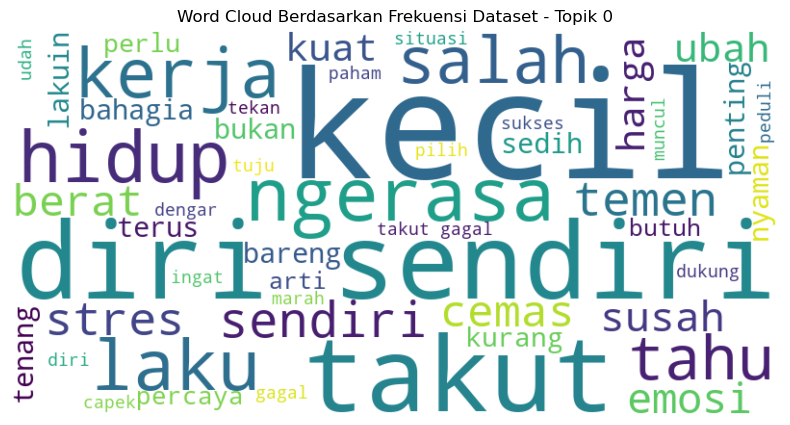

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np


file_path = r'C:\Users\Liza\Documents\Kerja Praktik\berttopic\exp-5\bertopic_results(5).csv'
df = pd.read_csv(file_path, sep=';')

def generate_wc_from_data(df, topic_id):
    subset = df[df['Topic'] == topic_id]
    
    if subset.empty:
        print(f"Topik {topic_id} tidak ditemukan.")
        return

    text_data = subset['document_preprocessed'].str.cat(sep=' ')
    
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        max_words=50 
    ).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    
    plt.imshow(wordcloud.to_image(), interpolation='bilinear')
    
    plt.title(f"Word Cloud Berdasarkan Frekuensi Dataset - Topik {topic_id}")
    plt.axis("off")
    plt.savefig(f'wordcloud_topic_{topic_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

generate_wc_from_data(df, 0)